# 05. Runtime Context

> 에이전트에는 **요청별로 바뀌는 정보**(사용자 ID, 세션 ID, 권한)가 흘러야 해요. Runtime이 Context · Store · Stream Writer를 어떻게 중개하는지 정리하고, 이 노트북에서는 특히 Context/Store/미들웨어 접근에 집중해요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. Runtime의 세 가지 구성 요소(Context, Store, Stream Writer)의 역할과 차이를 설명할 수 있어요
2. `dataclass`로 Context 스키마를 정의하고 에이전트 호출 시 주입하는 방법을 알아요
3. `ToolRuntime[ContextType]`을 사용해 도구 안에서 Context와 Store에 접근할 수 있어요
4. Stream Writer가 Runtime의 실시간 출력 통로임을 이해하고, 자세한 스트리밍 실습은 이전 노트북과 연결할 수 있어요
5. 미들웨어에서 Runtime을 활용해 동적 프롬프트, 권한 검사, 사용량 추적을 구현할 수 있어요

## 사전 지식

- Part 05의 `01-Create-Agent.ipynb` — `create_agent`, `AgentState`
- Part 05의 `02-Tools-V1.ipynb` — `@tool`, `ToolRuntime`
- Part 05의 `04-Streaming-V1.ipynb` — `stream_mode` 종류

## Runtime이란?

LangChain V1의 `create_agent`는 **Runtime**이라는 실행 환경을 에이전트 내부에 제공해요.  
도구는 실행 도중 Runtime을 통해 Context, Store, Stream Writer에 접근할 수 있고, 미들웨어도 Runtime을 통해 요청별 실행 정보를 활용할 수 있어요.

> 🔑 **핵심 개념**: Runtime을 **호텔 프론트 데스크**에 비유할 수 있어요. 호텔 투숙객(도구/미들웨어)은 프론트 데스크(Runtime)를 통해 객실 정보(Context), 금고(Store) 같은 실행 자원에 접근해요. 도구는 필요할 때 룸서비스 전화(Stream Writer)처럼 진행 상황도 밖으로 알릴 수 있어요. 각 투숙객이 직접 호텔 시스템에 들어갈 필요 없이, 프론트 데스크가 서비스를 중개해줘요.

| 구성 요소 | 유형 | 역할 | 접근 방법 |
|-----------|------|------|-----------|
| **Context** | 정적 | 사용자 ID, 언어, 사용자 등급 등 요청별 메타데이터 | `runtime.context` |
| **Store** | 동적 | 세션을 넘는 장기 메모리 읽기/쓰기 | `runtime.store.get()` / `.put()` |
| **Stream Writer** | 실시간 | 도구 진행 상황을 커스텀 스트림으로 전송 | `runtime.stream_writer(dict)` |

### Context vs State vs Store 비교

| 특성 | Context | State | Store |
|------|---------|-------|-------|
| **변경 가능** | 불변 (읽기 전용) | 변경 가능 (add_messages 등) | 변경 가능 (put/get) |
| **지속 범위** | 단일 invoke 호출 | 대화 세션 (thread_id) | 영구 (세션 간 공유) |
| **주입 방법** | `agent.invoke(..., context=)` | `agent.invoke({"messages": ...})` | `create_agent(store=)` |
| **대표 데이터** | user_id, 권한, API 키 | 메시지, 인증 상태 | 사용자 선호도, 검색 기록 |

> 💡 **실무 팁**: 도구 파라미터에 `ToolRuntime`을 넣으면 LLM에는 보이지 않고 에이전트 실행 엔진이 자동으로 값을 채워줘요.

```mermaid
flowchart LR
    %% 왼쪽에서 오른쪽으로 흐름을 나누어 선 겹침을 줄입니다.
    subgraph Request["요청"]
        direction TB
        User([사용자 요청])
        InputCtx["context=...<br/>(요청 메타데이터)"]
    end

    subgraph Execution["에이전트 내부 실행"]
        direction TB
        Agent[에이전트 실행]
        Tool[도구 실행]
        MW[미들웨어]
        Agent --> Tool
        Agent --> MW
    end

    subgraph RuntimeBox["Runtime<br/>(호텔 프론트 데스크)"]
        direction TB
        Runtime["ToolRuntime<br/>request.runtime"]
    end

    subgraph Resources["Runtime이 제공하는 자원"]
        direction TB
        Ctx["Context<br/>(정적 메타데이터)"]
        Store[("Store<br/>(장기 메모리)")]
        SW["Stream Writer<br/>(실시간 업데이트)"]
    end

    User --> Agent
    InputCtx -->|invoke 시 주입| Agent
    Tool -->|ToolRuntime| Runtime
    MW -->|request.runtime| Runtime
    Runtime -->|context| Ctx
    Runtime -->|store| Store
    Runtime -->|stream_writer| SW

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef runtime fill:#f8f9fa,stroke:#6c757d,color:#212529
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class User,InputCtx input
    class Agent,Tool,MW process
    class Runtime runtime
    class Ctx,Store storage
    class SW output
```

## 환경 설정

In [1]:
# 환경 변수 로드 (.env 파일에서 OPENAI_API_KEY 등을 읽어와요)
from dotenv import load_dotenv

load_dotenv()

# LangSmith 추적 설정 (선택 사항: 실행 흐름을 LangSmith 대시보드에서 확인할 수 있어요)
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Part05-Runtime"

In [2]:
# 기본 모델 초기화 — 모든 예제에서 공통으로 사용해요
from langchain.chat_models import init_chat_model

# 기본 모델: gpt-4o-mini (비용 효율, 학생 접근성)
# Anthropic 사용 시: "anthropic:claude-sonnet-4-5"
# Ollama 로컬 사용 시: "ollama:llama3"
model = init_chat_model("openai:gpt-4o-mini")

---

## 1. Context: 요청별 정적 메타데이터 주입

Context는 에이전트가 실행되는 동안 변경되지 않는 **요청별 메타데이터**예요.  
사용자 ID, 언어 설정, 권한 정보 등 "이 요청을 누가 어떤 상황에서 보냈는가"를 담아요.

### Context 정의와 주입 흐름

```python
@dataclass
class UserContext:
    user_id: str
    user_name: str
    language: str
```

1. `@dataclass`로 Context 스키마를 정의해요  
2. `create_agent(..., context_schema=UserContext)`로 에이전트에 등록해요  
3. `agent.invoke(..., context=UserContext(...))` 호출 시 값을 주입해요

여기까지는 **Context를 준비하고 호출에 실어 보내는 단계**예요.  
그 다음 질문은 "도구가 실행될 때 이 값을 어떻게 읽을까?"예요.

### 도구 안에서 Context를 읽는 방법

도구 함수는 LLM이 직접 실행하는 함수가 아니라, **LangChain 실행 엔진이 호출하는 함수**예요.  
그래서 도구 안에서 Context를 읽으려면 실행 엔진이 넣어주는 `runtime` 객체를 받아야 해요. 이때 사용하는 타입이 `ToolRuntime[UserContext]`예요.

```python
@tool
def get_user_info(runtime: ToolRuntime[UserContext]) -> str:
    user_name = runtime.context.user_name
    return f"현재 사용자는 {user_name}입니다."
```

즉, 흐름은 이렇게 나뉘어요.

| 단계 | 코드 | 의미 |
|------|------|------|
| Context 모양 정의 | `class UserContext: ...` | 어떤 메타데이터를 받을지 정해요 |
| Agent에 등록 | `context_schema=UserContext` | 이 에이전트가 받을 Context 타입을 알려줘요 |
| 호출 시 주입 | `context=UserContext(...)` | 이번 요청의 실제 사용자 정보를 넘겨요 |
| 도구에서 읽기 | `runtime.context.user_name` | 실행 중인 도구가 Context를 꺼내 써요 |

> 🎯 **강의 포인트**: `ToolRuntime`은 "도구가 Runtime에 접근하기 위한 통로"예요.  
> LLM에게 보이는 도구 입력이 아니라 LangChain이 자동으로 주입하는 실행 객체라서, 도구 schema에서는 제외돼요.

> 💡 **파라미터 구분**: `query: str`, `city: str`처럼 LLM이 채울 값은 일반 파라미터로 두고,  
> `runtime: ToolRuntime[...]`처럼 실행 엔진이 채울 값은 별도로 둬요. 예제에서는 읽기 쉽게 보통 마지막에 둡니다.


In [3]:
# ---------------------------------------------------
# 1-1. Context 스키마 정의 및 도구에서 접근
# ---------------------------------------------------
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.tools import tool, ToolRuntime


# Context 스키마: 사용자 정보를 담는 dataclass
@dataclass
class UserContext:
    user_id: str     # 사용자 고유 식별자
    user_name: str   # 표시 이름
    user_email: str  # 이메일 주소


# 도구 1: 현재 사용자 정보 조회 — runtime.context로 UserContext에 접근해요
@tool
def get_user_info(runtime: ToolRuntime[UserContext]) -> str:
    """Get information about the current user."""
    # runtime.context를 통해 UserContext 필드에 접근해요
    user_id = runtime.context.user_id
    user_name = runtime.context.user_name
    user_email = runtime.context.user_email
    return f"User ID: {user_id}, Name: {user_name}, Email: {user_email}"


# 도구 2: 개인화 인사 생성 — 이름을 Context에서 자동으로 가져와요
@tool
def personalized_greeting(runtime: ToolRuntime[UserContext]) -> str:
    """Generate a personalized greeting for the user."""
    user_name = runtime.context.user_name
    return f"안녕하세요, {user_name}님! 무엇을 도와드릴까요?"


# 에이전트 생성: context_schema를 지정해야 Context 주입이 활성화돼요
agent_context = create_agent(
    model=model,
    tools=[personalized_greeting, get_user_info],
    context_schema=UserContext,  # Context 스키마 등록
)

# 에이전트 생성 완료

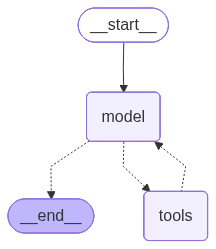

In [4]:
# 그래프 흐름: START → model → {tools_condition} → tools 또는 END
# model 노드: LLM이 사용자 메시지를 처리하고 도구 호출을 결정해요
# tools 노드: personalized_greeting 또는 get_user_info 도구를 실행해요
# runtime.context를 통해 UserContext(user_id, user_name, user_email)에 접근해요
from IPython.display import Image, display
display(Image(agent_context.get_graph().draw_mermaid_png()))

In [5]:
# ---------------------------------------------------
# 1-2. Context를 주입해서 에이전트 호출
# ---------------------------------------------------
# invoke 호출 시 context= 파라미터로 UserContext 인스턴스를 전달해요
result = agent_context.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요? 반갑습니다."}]},
    context=UserContext(
        user_id="user_123",
        user_name="김철수",
        user_email="chulsoo@example.com",
    ),
)

# 최종 응답 출력
print(result["messages"][-1].content)

안녕하세요! 반갑습니다. 어떻게 도와드릴까요?


In [6]:
# ---------------------------------------------------
# 1-3. 같은 에이전트, 다른 Context로 재사용
# ---------------------------------------------------
# 에이전트 코드는 그대로 — Context만 바꿔서 다른 사용자 시뮬레이션
result2 = agent_context.invoke(
    {"messages": [{"role": "user", "content": "내 정보를 알려줘."}]},
    context=UserContext(
        user_id="user_456",
        user_name="이영희",
        user_email="younghee@example.com",
    ),
)

print(result2["messages"][-1].content)

당신의 정보는 다음과 같습니다:

- **이름**: 이영희
- **이메일**: younghee@example.com
- **사용자 ID**: user_456


---

## 2. Store: 세션을 넘는 장기 메모리

Context가 요청 안에서만 사는 정적 데이터라면, **Store**는 여러 대화 세션에 걸쳐 데이터를 **읽고 쓸 수 있는** 영구 저장소예요.

### Store의 데이터 모델

| 개념 | 설명 | 예시 |
|------|------|------|
| **Namespace** | 튜플 형태의 논리 파티션 | `("users",)`, `("history", "user_123")` |
| **Key** | 네임스페이스 안의 항목 식별자 | `"user_123"`, `"prefs"` |
| **Value** | 저장할 dict 데이터 | `{"preferences": "간결한 스타일"}` |

```python
# 저장
runtime.store.put(("users",), "user_123", {"preferences": "간결한 스타일"})

# 조회 — 없으면 None 반환
item = runtime.store.get(("users",), "user_123")
value = item.value  # {"preferences": "간결한 스타일"}
```

> 💡 **실무 팁**: 개발/테스트 환경에서는 `InMemoryStore`를, 프로덕션에서는 `PostgresSaver` 등 영속 백엔드로 교체해요.  
> `create_agent(..., store=store)` 인자만 바꾸면 되므로 코드 수정이 최소화돼요.

> ⚠️ **자주 하는 실수**: `runtime.store.get()` 결과가 `None`일 수 있어요.  
> `if item := runtime.store.get(...):` 패턴으로 None 체크를 항상 해주세요.

In [7]:
# ---------------------------------------------------
# 2-1. InMemoryStore 초기화 및 초기 데이터 설정
# ---------------------------------------------------
from langgraph.store.memory import InMemoryStore

# 인메모리 Store 생성 (프로덕션에서는 PostgresStore 등으로 교체)
store = InMemoryStore()

# 초기 데이터 삽입: (namespace_tuple, key, value_dict)
store.put(
    ("users",),           # 네임스페이스: 사용자 데이터 파티션
    "user_123",           # 키: 사용자 ID
    {"preferences": "상세하고 기술적인 설명을 선호합니다."},  # 값
)

# 저장된 데이터 확인
item = store.get(("users",), "user_123")
print(f"초기 설정: {item.value}")

초기 설정: {'preferences': '상세하고 기술적인 설명을 선호합니다.'}


In [8]:
# ---------------------------------------------------
# 2-2. Store를 사용하는 도구 정의
# ---------------------------------------------------
@dataclass
class SimpleContext:
    user_id: str  # Store 조회 키로 사용해요


# 도구: 사용자 이메일 작성 스타일 설정 조회
@tool
def fetch_user_preferences(runtime: ToolRuntime[SimpleContext]) -> str:
    """Fetch the user's email writing style preferences from the store."""
    user_id = runtime.context.user_id

    # Store에 데이터가 없으면 기본값 반환
    default = "사용자는 간결하고 정중한 이메일 작성을 선호합니다."

    if runtime.store:
        if memory := runtime.store.get(("users",), user_id):  # None 체크
            return memory.value["preferences"]

    return default


# 도구: 사용자 설정 저장
@tool
def save_user_preference(preference: str, runtime: ToolRuntime[SimpleContext]) -> str:
    """Save user's preference setting to the store."""
    user_id = runtime.context.user_id

    if runtime.store:
        # 새 설정을 Store에 기록 (덮어쓰기)
        runtime.store.put(("users",), user_id, {"preferences": preference})
        return f"설정이 저장되었어요: {preference}"

    return "Store를 사용할 수 없어요."


# Store를 에이전트에 연결 — store= 인자로 전달해요
agent_store = create_agent(
    model=model,
    tools=[fetch_user_preferences, save_user_preference],
    context_schema=SimpleContext,
    store=store,  # Store 연결
)

# Store 연결 에이전트 생성 완료

In [9]:
# ---------------------------------------------------
# 2-3. Store에서 사용자 설정 읽기
# ---------------------------------------------------
result = agent_store.invoke(
    {"messages": [{"role": "user", "content": "제 이메일 작성 스타일 설정이 어떻게 되어 있나요?"}]},
    context=SimpleContext(user_id="user_123"),  # Store 조회 키로 사용
)

print(result["messages"][-1].content)

당신의 이메일 작성 스타일 설정은 "상세하고 기술적인 설명"을 선호하는 것으로 되어 있습니다. 추가로 조정하고 싶은 사항이 있으신가요?


In [10]:
# ---------------------------------------------------
# 2-4. Store에 새 설정 쓰기 → 다시 읽어서 반영 확인
# ---------------------------------------------------
# 설정 업데이트 요청
result = agent_store.invoke(
    {"messages": [{"role": "user", "content": "앞으로는 짧고 친근한 스타일로 이메일을 쓰고 싶어요. 설정을 바꿔줘요."}]},
    context=SimpleContext(user_id="user_123"),
)
print("[업데이트 후 응답]", result["messages"][-1].content)

# Store 직접 확인 — 실제로 변경되었는지 검증해요
item = store.get(("users",), "user_123")
print(f"\n[Store 직접 조회] {item.value}")

[업데이트 후 응답] 설정이 "짧고 친근한 스타일"로 저장되었어요! 앞으로 이메일을 이렇게 작성할게요. 😊

[Store 직접 조회] {'preferences': '짧고 친근한 스타일'}


---

## 3. Stream Writer: Runtime 안의 실시간 출력 통로

Stream Writer는 Runtime이 제공하는 세 번째 자원이에요.  
다만 `stream_mode="custom"`, 진행률 바, 다중 스트리밍 모드는 이미 `04-Streaming-V1.ipynb`에서 자세히 다뤘으므로, 여기서는 **Runtime 관점에서 어디에 붙어 있는지**만 짚고 넘어가요.

### Runtime 관점에서 보는 흐름

1. 도구가 `ToolRuntime`을 통해 현재 실행의 Runtime 객체를 받아요  
2. 도구 내부에서 `runtime.stream_writer({...})`로 커스텀 이벤트를 내보내요  
3. 호출자는 `.stream(..., stream_mode="custom")`으로 그 이벤트를 받아요

```python
@tool
def long_running_tool(runtime: ToolRuntime) -> str:
    runtime.stream_writer({"stage": "working"})
    return "done"
```

> 🎯 **강의 포인트**: `stream_writer`는 새로운 저장소나 상태가 아니라, **도구 실행 중간 이벤트를 밖으로 내보내는 Runtime의 출력 채널**이에요.  
> 실제 진행률 표시, `updates + custom` 다중 모드, UI 출력 패턴은 이전 `04-Streaming-V1.ipynb`의 예제를 재사용하면 돼요.


---

## 4. 미들웨어에서 Runtime 접근

미들웨어도 도구와 동일하게 Runtime에 접근할 수 있어요.  
미들웨어에서 Context를 읽으면 **사용자별로 프롬프트나 동작을 다르게 만들 수 있어요**.

### 미들웨어 종류별 접근 방식

| 미들웨어 데코레이터 | Runtime 접근 방법 | 주요 용도 |
|--------------------|-------------------|-----------|
| `@dynamic_prompt` | `request.runtime.context` | 사용자별 시스템 프롬프트 생성 |
| `@before_model` | `runtime: Runtime[ContextType]` 파라미터 | 모델 호출 전 로깅/검증 |
| `@after_model` | `runtime: Runtime[ContextType]` 파라미터 | 응답 후 비용 추적/변환 |
| `@before_agent` | `runtime: Runtime[ContextType]` 파라미터 | 권한 검사, 조기 종료 |

> 🔑 **핵심 개념**: 미들웨어 파이프라인 실행 순서는  
> `@before_agent` → `@dynamic_prompt` → `@before_model` → 모델 호출 → `@after_model`  
> 이 순서를 이해하면 어떤 미들웨어에서 어떤 처리를 해야 할지 명확해져요.

In [11]:
# ---------------------------------------------------
# 4-1. @dynamic_prompt: 사용자 언어에 따른 동적 시스템 프롬프트
# ---------------------------------------------------
from langchain.agents.middleware import dynamic_prompt, ModelRequest


# Context 스키마 — 언어 설정 포함
@dataclass
class LanguageContext:
    user_name: str  # 사용자 이름
    language: str   # "ko" 또는 "en"


# 날씨 조회 도구 (간단한 더미 구현)
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    # 실제 API 대신 고정값 반환
    return f"The weather in {city} is sunny and 22°C."


# @dynamic_prompt: 요청마다 실행되어 시스템 프롬프트를 동적으로 반환해요
@dynamic_prompt
def language_aware_prompt(request: ModelRequest) -> str:
    # request.runtime.context로 LanguageContext에 접근해요
    user_name = request.runtime.context.user_name
    language = request.runtime.context.language

    # 언어에 따라 다른 시스템 프롬프트를 생성해요
    if language == "ko":
        return (
            f"당신은 친절한 날씨 도우미입니다. "
            f"사용자를 '{user_name}님'으로 호칭하고 항상 한국어로 응답하세요."
        )
    else:
        return (
            f"You are a helpful weather assistant. "
            f"Address the user as '{user_name}' and always respond in English."
        )


# 동적 프롬프트 미들웨어를 포함한 에이전트
agent_lang = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[language_aware_prompt],  # 미들웨어 등록
    context_schema=LanguageContext,
)

# 동적 프롬프트 에이전트 생성 완료

In [12]:
# ---------------------------------------------------
# 4-2. 같은 질문, 다른 언어 Context — 응답 언어가 달라져요
# ---------------------------------------------------
question = "What's the weather in Seoul?"

# 한국어 사용자
# === 한국어 사용자 ===
result_ko = agent_lang.invoke(
    {"messages": [{"role": "user", "content": question}]},
    context=LanguageContext(user_name="김철수", language="ko"),
)
print(result_ko["messages"][-1].content)

# 영어 사용자
# === English User ===
result_en = agent_lang.invoke(
    {"messages": [{"role": "user", "content": question}]},
    context=LanguageContext(user_name="Alice", language="en"),
)
print(result_en["messages"][-1].content)

김철수님, 현재 서울의 날씨는 맑고 기온은 22도입니다.
The weather in Seoul is sunny with a temperature of 22°C.


In [13]:
# ---------------------------------------------------
# 4-3. @before_model / @after_model: 모델 호출 전후 처리
# ---------------------------------------------------
from langchain.agents import AgentState
from langchain.agents.middleware import before_model, after_model
from langgraph.runtime import Runtime


# Context 스키마 — 세션 정보 포함
@dataclass
class SessionContext:
    user_name: str   # 사용자 이름
    session_id: str  # 세션 식별자 (로깅/추적용)


# @before_model: 모델 호출 직전에 실행돼요 — 로깅, 입력 검증에 적합해요
@before_model
def log_before_model(state: AgentState, runtime: Runtime[SessionContext]) -> dict | None:
    """모델 호출 전 세션 정보와 메시지 수를 로깅해요"""
    print(
        f"[Before] 사용자: {runtime.context.user_name}, "
        f"세션: {runtime.context.session_id}, "
        f"메시지 수: {len(state['messages'])}"
    )
    return None  # None을 반환하면 상태를 변경하지 않아요


# @after_model: 모델 응답 직후에 실행돼요 — 비용 추적, 후처리에 적합해요
@after_model
def log_after_model(state: AgentState, runtime: Runtime[SessionContext]) -> dict | None:
    """모델 응답 후 완료 로그를 기록해요"""
    print(
        f"[After]  세션 {runtime.context.session_id} — "
        f"{runtime.context.user_name}에게 응답 생성 완료"
    )
    return None


# before_model + after_model 미들웨어를 함께 등록
agent_logging = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[log_before_model, log_after_model],  # 두 미들웨어 등록
    context_schema=SessionContext,
)

# 호출 시 로그가 출력되는지 확인해요
result = agent_logging.invoke(
    {"messages": [{"role": "user", "content": "서울 날씨는 어때?"}]},
    context=SessionContext(user_name="이영희", session_id="sess_789"),
)
print(f"\n[응답] {result['messages'][-1].content}")

[Before] 사용자: 이영희, 세션: sess_789, 메시지 수: 1
[After]  세션 sess_789 — 이영희에게 응답 생성 완료
[Before] 사용자: 이영희, 세션: sess_789, 메시지 수: 3
[After]  세션 sess_789 — 이영희에게 응답 생성 완료

[응답] 서울의 날씨는 맑고 기온은 22°C입니다.


---

## 5. @before_agent: 권한 검사와 조기 종료

`@before_agent` 미들웨어는 에이전트 루프 진입 전에 실행돼요.  
권한이 없는 요청을 **에이전트가 LLM을 호출하기도 전에 차단**할 수 있어서 비용을 절약해요.

`can_jump_to=["end"]` 옵션을 지정하면 미들웨어가 `"jump_to": "end"`를 반환해서 즉시 종료할 수 있어요.

> 🎯 **강의 포인트**: `@before_agent`에서 `{"jump_to": "end", "messages": [...]}` 를 반환하면  
> LLM 호출 없이 바로 응답을 반환해요. API 비용을 0으로 만드는 가장 효율적인 차단 방식이에요.

> 💡 **실무 팁**: 인증 토큰 검증, 요금제 사용량 초과 차단, 욕설 필터 등에 `@before_agent`를 활용해요.  
> 비즈니스 규칙은 LLM에게 맡기지 말고 코드 레벨에서 명확히 처리하는 게 안전해요.

In [14]:
# ---------------------------------------------------
# 5-1. @before_agent: 관리자 권한 검사
# ---------------------------------------------------
from langchain.agents.middleware import before_agent
from typing import Any


# 권한 정보를 담는 Context 스키마
@dataclass
class AuthContext:
    user_id: str
    permissions: list  # 예: ["user", "read", "write"] 또는 ["admin", "delete"]


# @before_agent: 에이전트 루프 시작 전 권한을 검사해요
# can_jump_to=["end"] — "end" 노드로 점프할 수 있다고 선언해요
@before_agent(can_jump_to=["end"])
def check_permissions(
    state: AgentState, runtime: Runtime[AuthContext]
) -> dict[str, Any] | None:
    """관리자 전용 작업에 대한 권한을 사전에 검사해요"""
    permissions = runtime.context.permissions

    # 메시지 내용을 소문자로 변환해서 민감한 키워드를 탐지해요
    if state["messages"]:
        content = state["messages"][0].content.lower()

        # "delete" 또는 "remove" 요청 → admin 권한 필요
        if ("delete" in content or "remove" in content) and "admin" not in permissions:
            # jump_to="end"로 즉시 에이전트 루프를 종료해요
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "이 작업은 관리자 권한이 필요해요. 접근이 거부되었습니다.",
                    }
                ],
                "jump_to": "end",  # 즉시 종료
            }

    return None  # None을 반환하면 에이전트 루프를 정상 진행해요


# 권한 검사 미들웨어가 포함된 에이전트
agent_auth = create_agent(
    model=model,
    tools=[],  # 도구 없이 권한 검사만 테스트
    middleware=[check_permissions],
    context_schema=AuthContext,
)

# 권한 검사 에이전트 생성 완료

In [15]:
# ---------------------------------------------------
# 5-2. 권한이 없는 사용자 — 차단 확인
# ---------------------------------------------------
# === 권한 없는 사용자 (일반 회원) ===
result_denied = agent_auth.invoke(
    {"messages": [{"role": "user", "content": "Delete all user data"}]},
    context=AuthContext(
        user_id="user_123",
        permissions=["user", "read", "write"],  # admin 없음
    ),
)
print(result_denied["messages"][-1].content)

print()

# ---------------------------------------------------
# 5-3. 권한이 있는 사용자 — 정상 통과
# ---------------------------------------------------
# === 권한 있는 사용자 (관리자) ===
result_allowed = agent_auth.invoke(
    {"messages": [{"role": "user", "content": "Delete all user data"}]},
    context=AuthContext(
        user_id="admin_001",
        permissions=["admin", "user", "read", "write", "delete"],  # admin 포함
    ),
)
print(result_allowed["messages"][-1].content)

이 작업은 관리자 권한이 필요해요. 접근이 거부되었습니다.

I don't have the capability to store or delete user data. Each interaction is stateless and doesn't retain past information. If you have any specific privacy concerns or questions, feel free to ask!


---

## 6. 종합 예제: 사용자 등급 기반 에이전트

지금까지 배운 Context, Store, 미들웨어를 조합한 실전 예제예요.  
사용자 등급(`free` / `premium` / `enterprise`)에 따라 도구 응답과 프롬프트가 달라지고,  
검색 기록은 Store에 저장되며, 사용량은 미들웨어가 추적해요.

> 🎯 **강의 포인트**: 이 패턴은 SaaS 제품에서 매우 자주 사용해요.  
> 비즈니스 로직(등급별 기능 제한)을 LLM 프롬프트 안에 넣지 않고,  
> Context + 미들웨어로 코드 레벨에서 명확하게 처리하는 게 핵심이에요.

In [16]:
# ---------------------------------------------------
# 6-1. 종합 예제 구성 요소 정의
# ---------------------------------------------------
from langchain.agents.middleware import dynamic_prompt, ModelRequest, before_model
from langgraph.store.memory import InMemoryStore


# Context 스키마 — 사용자 등급 포함
@dataclass
class TierContext:
    user_id: str
    user_name: str
    user_tier: str   # "free" | "premium" | "enterprise"
    language: str    # "ko" | "en"


# --- 도구 정의 ---

@tool
def search_database(query: str, runtime: ToolRuntime[TierContext]) -> str:
    """Search the database. Access level depends on user tier."""
    user_tier = runtime.context.user_tier

    # 등급별로 다른 응답을 반환해요 (비즈니스 로직이 도구 안에 있어요)
    if user_tier == "enterprise":
        return f"[Enterprise] '{query}' 전체 데이터베이스 검색 결과 (무제한)"
    elif user_tier == "premium":
        return f"[Premium] '{query}' 검색 결과 (상위 100건)"
    else:
        return f"[Free] '{query}' 검색 결과 (상위 10건 — 업그레이드 시 더 많은 결과)"


@tool
def get_search_history(runtime: ToolRuntime[TierContext]) -> str:
    """Get the user's recent search history from persistent store."""
    user_id = runtime.context.user_id

    if runtime.store:
        if history := runtime.store.get(("history",), user_id):
            searches = history.value.get("searches", [])
            return f"최근 검색 기록: {searches}"

    return "검색 기록이 없어요."


@tool
def save_search_query(query: str, runtime: ToolRuntime[TierContext]) -> str:
    """Save a search query to the user's history."""
    user_id = runtime.context.user_id

    if runtime.store:
        existing = runtime.store.get(("history",), user_id)
        searches = existing.value["searches"] if existing else []

        # 최근 5개 검색어만 유지
        searches.append(query)
        runtime.store.put(("history",), user_id, {"searches": searches[-5:]})
        return f"검색어 '{query}'를 기록했어요."

    return "Store를 사용할 수 없어요."


# --- 미들웨어 정의 ---

@dynamic_prompt
def tier_based_prompt(request: ModelRequest) -> str:
    """사용자 등급과 언어에 따라 시스템 프롬프트를 생성해요"""
    user_name = request.runtime.context.user_name
    language = request.runtime.context.language
    user_tier = request.runtime.context.user_tier

    # 등급 설명 (언어별)
    tier_desc = {
        "ko": {"free": "무료", "premium": "프리미엄", "enterprise": "엔터프라이즈"},
        "en": {"free": "Free", "premium": "Premium", "enterprise": "Enterprise"},
    }.get(language, {})

    tier_label = tier_desc.get(user_tier, user_tier)

    if language == "ko":
        return (
            f"당신은 도움이 되는 검색 어시스턴트입니다. "
            f"사용자를 '{user_name}님'으로 호칭하고 항상 한국어로 응답하세요. "
            f"이 사용자는 {tier_label} 회원입니다."
        )
    else:
        return (
            f"You are a helpful search assistant. "
            f"Address the user as '{user_name}' and always respond in English. "
            f"This is a {tier_label} tier user."
        )


@before_model
def track_usage(state: AgentState, runtime: Runtime[TierContext]) -> dict | None:
    """무료 사용자의 API 호출 횟수를 추적해요"""
    user_id = runtime.context.user_id
    user_tier = runtime.context.user_tier

    # 무료 사용자만 사용량 추적
    if user_tier == "free" and runtime.store:
        usage = runtime.store.get(("usage",), user_id)
        count = usage.value["count"] if usage else 0

        print(f"[사용량 추적] {user_id} (무료): 현재 {count + 1}회 사용")
        runtime.store.put(("usage",), user_id, {"count": count + 1})

    return None


# 종합 예제 구성 요소 정의 완료

In [17]:
# ---------------------------------------------------
# 6-2. Store 초기화 및 에이전트 생성
# ---------------------------------------------------
# 공유 Store — 모든 사용자의 데이터를 담아요
shared_store = InMemoryStore()

# 사용자 001의 기존 검색 기록 초기화
shared_store.put(
    ("history",), "ent_001",
    {"searches": ["LangGraph tutorial", "Python asyncio"]},
)

# 종합 에이전트 생성
agent_tier = create_agent(
    model=model,
    tools=[search_database, get_search_history, save_search_query],
    middleware=[tier_based_prompt, track_usage],
    context_schema=TierContext,
    store=shared_store,  # 공유 Store 연결
)

# 종합 에이전트 생성 완료

In [18]:
# ---------------------------------------------------
# 6-3. 엔터프라이즈 사용자 — 전체 결과 접근
# ---------------------------------------------------
# === 엔터프라이즈 사용자 ===
result_ent = agent_tier.invoke(
    {"messages": [{"role": "user", "content": "머신러닝을 검색해줘"}]},
    context=TierContext(
        user_id="ent_001", user_name="박지훈",
        user_tier="enterprise", language="ko",
    ),
)
print(result_ent["messages"][-1].content)

검색 결과를 찾을 수 없습니다. 머신러닝에 대한 특정한 질문이나 관심 있는 주제가 있으시면 말씀해주시면 더 도움이 될 수 있습니다.


In [19]:
# ---------------------------------------------------
# 6-4. 무료 사용자 — 제한된 결과 + 사용량 추적
# ---------------------------------------------------
# === 무료 사용자 ===
result_free = agent_tier.invoke(
    {"messages": [{"role": "user", "content": "Search for data science"}]},
    context=TierContext(
        user_id="free_002", user_name="Jane",
        user_tier="free", language="en",
    ),
)
print(result_free["messages"][-1].content)

[사용량 추적] free_002 (무료): 현재 1회 사용
[사용량 추적] free_002 (무료): 현재 2회 사용
I found some results for "data science." However, as a free tier user, you can only see a limited number of results. If you're looking for something specific within data science, let me know!


In [20]:
# ---------------------------------------------------
# 6-5. 기존 검색 기록 조회 (Store에서 읽기)
# ---------------------------------------------------
# === 검색 기록 조회 ===
result_history = agent_tier.invoke(
    {"messages": [{"role": "user", "content": "내 검색 기록을 보여줘"}]},
    context=TierContext(
        user_id="ent_001", user_name="박지훈",
        user_tier="enterprise", language="ko",
    ),
)
print(result_history["messages"][-1].content)

박지훈님, 최근 검색 기록은 다음과 같습니다:

1. LangGraph tutorial
2. Python asyncio

더 궁금한 사항이 있으신가요?


---

## 실습 해설: 실습 — 나만의 Context 확장하기

아래 코드를 수정해서 새로운 Context 필드를 추가하고, 도구 동작을 바꿔보세요.

In [21]:
# ============================================================
# 실습 해설: region Context 확장하기
# ============================================================

from dataclasses import dataclass
from langchain.tools import tool, ToolRuntime
from langchain.agents import create_agent


@dataclass
class MyContext:
    user_id: str
    user_name: str
    region: str = "KR"


@tool
def search_by_region(query: str, runtime: ToolRuntime[MyContext]) -> str:
    """Search with region-specific results."""
    region = runtime.context.region.upper()
    if region == "KR":
        return f"[한국] '{query}' 관련 국내 뉴스와 정책 자료 검색 결과"
    if region == "US":
        return f"[US] Search results for '{query}' from US sources"
    return f"[{region}] Search results for: {query}"


agent_todo = create_agent(
    model=model,
    tools=[search_by_region],
    context_schema=MyContext,
)

result = agent_todo.invoke(
    {"messages": [{"role": "user", "content": "AI 뉴스를 검색해줘"}]},
    context=MyContext(user_id="test_001", user_name="테스터", region="KR"),
)
print(result["messages"][-1].content)


현재 "AI 뉴스" 또는 "인공지능 뉴스"에 대한 검색 결과가 없습니다. 원하시는 특정 주제나 키워드가 있을 경우 알려주시면 더 도움이 될 수 있습니다!


---

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **Runtime 3요소**: Context(정적 메타), Store(영속 메모리), Stream Writer(실시간 출력 채널)가 Runtime을 통해 도구/미들웨어와 연결돼요
- **Context 주입 패턴**: `@dataclass`로 스키마 정의 → `context_schema=` 등록 → 호출 시 `context=` 주입 → 도구에서 `ToolRuntime[T]`로 접근
- **ToolRuntime 자동 주입**: `ToolRuntime` 파라미터는 LLM에 노출되지 않고 에이전트 엔진이 자동으로 값을 채워줘요
- **Store CRUD**: `put(namespace, key, value)`로 쓰고 `get(namespace, key)`로 읽어요. `None` 체크 필수
- **Stream Writer 위치**: 이 노트북에서는 Runtime의 출력 채널이라는 역할만 짚고, 자세한 `stream_mode="custom"` 실습은 `04-Streaming-V1.ipynb`로 분리했어요
- **미들웨어 활용**: `@dynamic_prompt`는 요청별 시스템 프롬프트, `@before_model`/`@after_model`은 모델 호출 전후 처리, `@before_agent`는 권한 검사와 조기 종료에 사용해요
- **비즈니스 로직 분리**: 등급별 기능 제한, 사용량 추적 등 비즈니스 규칙은 LLM 프롬프트가 아닌 Context + 미들웨어 코드 레벨에서 처리해요

---


## 다음 노트북 예고

다음 `06-MCP-Server-Basics.ipynb`에서는 **MCP(Model Context Protocol) 서버 만들기**를 배워요. `FastMCP`와 `@mcp.tool()` 데코레이터로 도구를 서버로 노출하고, stdio / HTTP 전송 방식을 선택하는 방법, MCP Inspector로 서버를 가시화하는 방법까지 다뤄요. 에이전트에 붙일 도구를 독립 서비스로 분리해 여러 팀과 공유할 수 있어요.